<a href="https://colab.research.google.com/github/majnumiah1588/AI_Lab/blob/main/notebooks/CNN_BinaryClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# ============================================================
# CELL 1 : Environment Setup
# Purpose:
# - Check TensorFlow & GPU
# - Import required libraries
# - Mount Google Drive
# - Set random seeds
# ============================================================

# Check TensorFlow version
import tensorflow as tf
print("="*60)
print("TensorFlow Version :", tf.__version__)
print("="*60)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 0:
    print("GPU Found :", gpus[0])
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Memory Growth Enabled")
    except:
        pass
else:
    print("No GPU Found!")

print("="*60)

# -------------------------------
# Import Required Libraries
# -------------------------------

import os
import cv2
import shutil
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Input,
    Rescaling,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# -------------------------------
# Set Random Seed
# -------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------------
# Mount Google Drive
# -------------------------------

from google.colab import drive
drive.mount('/content/drive')

print("\nEnvironment Ready Successfully.")

TensorFlow Version : 2.20.0
GPU Found : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU Memory Growth Enabled
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Environment Ready Successfully.


Extracting Dataset...
Extraction Completed.

Dataset Path Found:
/content/dataset

Detected Classes:
['aam_pata', 'kathal_pata']

Image Count
----------------------------------------
aam_pata             : 2487
kathal_pata          : 2461
----------------------------------------
Total Images : 4948

Dataset Structure

dataset/
    kathal_pata/
        image1865.jpeg
        image2024.jpg
        image884.jpg
    aam_pata/
        image1865.jpeg
        image2024.jpg
        image884.jpg


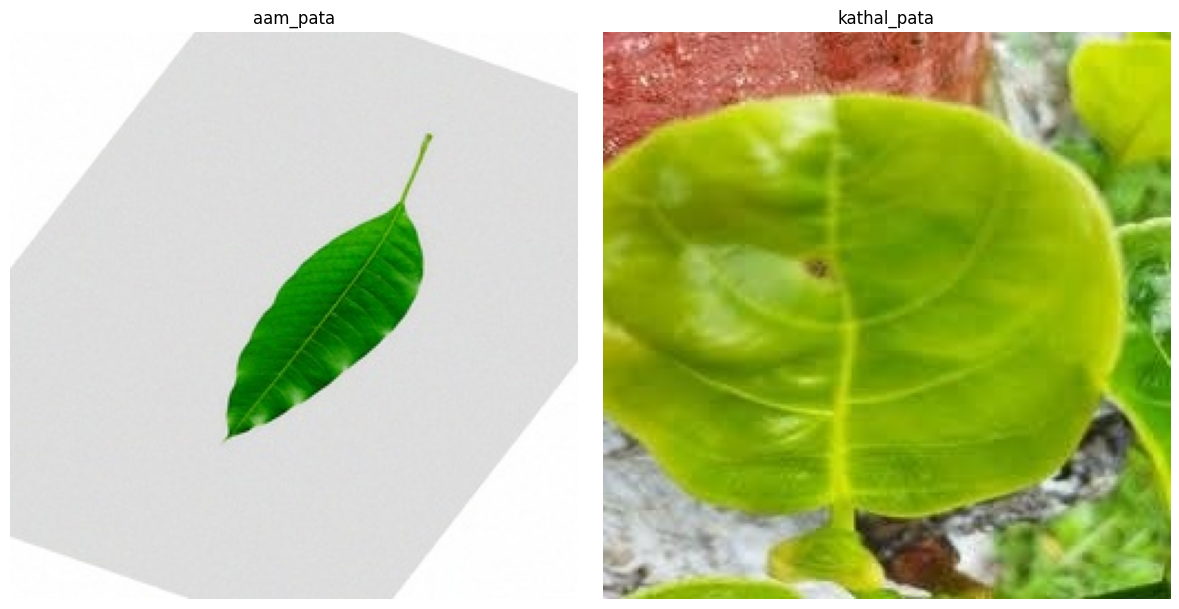


Dataset Verification Completed Successfully.


In [25]:
# ============================================================
# CELL 2 : Dataset Extraction & Verification
# Purpose:
# - Unzip dataset from Google Drive
# - Verify folder structure
# - Count images
# - Display sample images
# ============================================================

# -------------------------------
# Dataset Paths
# -------------------------------

ZIP_PATH = "/content/drive/MyDrive/leaf_dataset/dataset.zip"

EXTRACT_DIR = "/content"

DATASET_DIR = os.path.join(EXTRACT_DIR, "dataset")

# -------------------------------
# Remove Existing Dataset (Optional)
# -------------------------------

if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

# -------------------------------
# Extract ZIP File
# -------------------------------

print("Extracting Dataset...")

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction Completed.")

# -------------------------------
# Verify Dataset Path
# -------------------------------

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError("Dataset folder not found!")

print("\nDataset Path Found:")
print(DATASET_DIR)

# -------------------------------
# Class Information
# -------------------------------

classes = sorted(os.listdir(DATASET_DIR))

print("\nDetected Classes:")
print(classes)

# -------------------------------
# Count Images
# -------------------------------

print("\nImage Count")
print("-"*40)

total_images = 0

for cls in classes:

    class_path = os.path.join(DATASET_DIR, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))
    ]

    print(f"{cls:20s} : {len(images)}")

    total_images += len(images)

print("-"*40)
print("Total Images :", total_images)

# -------------------------------
# Dataset Structure
# -------------------------------

print("\nDataset Structure\n")

for root, dirs, files in os.walk(DATASET_DIR):

    level = root.replace(DATASET_DIR, "").count(os.sep)

    indent = " " * (4 * level)

    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * (4 * (level + 1))

    for f in files[:3]:
        print(f"{subindent}{f}")

# -------------------------------
# Display Sample Images
# -------------------------------

plt.figure(figsize=(12,6))

index = 1

for cls in classes:

    class_path = os.path.join(DATASET_DIR, cls)

    image_name = random.choice(os.listdir(class_path))

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(1, len(classes), index)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

    index += 1

plt.tight_layout()
plt.show()

print("\nDataset Verification Completed Successfully.")

In [26]:
# ============================================================
# CELL 3 : Dataset Splitting
# Purpose:
# - Create train/validation/test folders
# - Randomly split images
# - Split ratio:
#       Train = 70%
#       Validation = 10%
#       Test = 20%
# - Reproducible using seed=42
# ============================================================

# -------------------------------
# Define Paths
# -------------------------------

SOURCE_DIR = "/content/dataset"

NEW_DATASET_DIR = "/content/leaf_dataset"

TRAIN_DIR = os.path.join(NEW_DATASET_DIR, "train")
VAL_DIR = os.path.join(NEW_DATASET_DIR, "val")
TEST_DIR = os.path.join(NEW_DATASET_DIR, "test")


# -------------------------------
# Remove Previous Split Dataset
# -------------------------------

if os.path.exists(NEW_DATASET_DIR):
    shutil.rmtree(NEW_DATASET_DIR)


# -------------------------------
# Create Folder Structure
# -------------------------------

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    for cls in classes:

        os.makedirs(
            os.path.join(split_dir, cls),
            exist_ok=True
        )


# -------------------------------
# Split Images Function
# -------------------------------

def split_dataset(source_class_dir, class_name):

    images = [
        f for f in os.listdir(source_class_dir)
        if f.lower().endswith(
            ('.jpg','.jpeg','.png','.bmp','.webp')
        )
    ]


    # Random shuffle
    random.seed(SEED)
    random.shuffle(images)


    # Train 70%
    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=SEED
    )


    # Validation 10%, Test 20%
    val_images, test_images = train_test_split(
        temp_images,
        test_size=2/3,
        random_state=SEED
    )


    print(f"\nClass : {class_name}")
    print("-----------------------------")
    print("Total :", len(images))
    print("Train :", len(train_images))
    print("Val   :", len(val_images))
    print("Test  :", len(test_images))


    # Copy files
    for img in train_images:

        shutil.copy(
            os.path.join(source_class_dir,img),
            os.path.join(TRAIN_DIR,class_name,img)
        )


    for img in val_images:

        shutil.copy(
            os.path.join(source_class_dir,img),
            os.path.join(VAL_DIR,class_name,img)
        )


    for img in test_images:

        shutil.copy(
            os.path.join(source_class_dir,img),
            os.path.join(TEST_DIR,class_name,img)
        )


# -------------------------------
# Execute Split For Both Classes
# -------------------------------

for cls in classes:

    class_folder = os.path.join(
        SOURCE_DIR,
        cls
    )

    split_dataset(
        class_folder,
        cls
    )


# -------------------------------
# Verify New Dataset
# -------------------------------

print("\n\nFinal Dataset Structure")
print("="*50)


for root, dirs, files in os.walk(NEW_DATASET_DIR):

    level = root.replace(
        NEW_DATASET_DIR,""
    ).count(os.sep)

    indent = " "*4*level

    print(
        indent + os.path.basename(root) + "/"
    )

    for file in files[:2]:

        print(
            indent+"    "+file
        )


print("\nDataset Split Completed Successfully.")


Class : aam_pata
-----------------------------
Total : 2487
Train : 1740
Val   : 249
Test  : 498

Class : kathal_pata
-----------------------------
Total : 2461
Train : 1722
Val   : 246
Test  : 493


Final Dataset Structure
leaf_dataset/
    val/
        kathal_pata/
            image699.jpg
            image2120.jpg
        aam_pata/
            image987.jpg
            image819.jpg
    train/
        kathal_pata/
            image2024.jpg
            image884.jpg
        aam_pata/
            image1865.jpeg
            image2024.jpg
    test/
        kathal_pata/
            image1865.jpeg
            image987.jpg
        aam_pata/
            image1248.png
            image1266.jpg

Dataset Split Completed Successfully.


In [27]:
# ============================================================
# CELL 4 : TensorFlow Dataset Pipeline
# Purpose:
# - Load images using TensorFlow
# - Resize images to 256x256
# - Create batches
# - Optimize GPU performance using AUTOTUNE
# ============================================================


# -------------------------------
# Dataset Parameters
# -------------------------------

IMAGE_SIZE = (256,256)

BATCH_SIZE = 32


# -------------------------------
# Load Training Dataset
# -------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    seed=SEED,

    shuffle=True

)


# -------------------------------
# Load Validation Dataset
# -------------------------------

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    seed=SEED,

    shuffle=False

)


# -------------------------------
# Load Test Dataset
# -------------------------------

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    seed=SEED,

    shuffle=False

)



# -------------------------------
# Class Names
# -------------------------------

class_names = train_ds.class_names

print("\nClass Names:")
print(class_names)



# -------------------------------
# Dataset Shape Check
# -------------------------------

for images, labels in train_ds.take(1):

    print("\nImage Batch Shape:")
    print(images.shape)

    print("\nLabel Batch Shape:")
    print(labels.shape)



# -------------------------------
# Dataset Batch Count
# -------------------------------

print("\nNumber of Batches")
print("-----------------------")

print(
    "Training Batches :",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation Batches :",
    tf.data.experimental.cardinality(val_ds).numpy()
)

print(
    "Testing Batches :",
    tf.data.experimental.cardinality(test_ds).numpy()
)



# -------------------------------
# Optimize Pipeline
# -------------------------------

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.cache().shuffle(
    1000
).prefetch(
    buffer_size=AUTOTUNE
)


val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)


test_ds = test_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)


print("\nTensorFlow Data Pipeline Ready.")

Found 3462 files belonging to 2 classes.
Found 495 files belonging to 2 classes.
Found 991 files belonging to 2 classes.

Class Names:
['aam_pata', 'kathal_pata']

Image Batch Shape:
(32, 256, 256, 3)

Label Batch Shape:
(32,)

Number of Batches
-----------------------
Training Batches : 109
Validation Batches : 16
Testing Batches : 31

TensorFlow Data Pipeline Ready.


In [28]:
# ============================================================
# FIX : Recreate Data Augmentation Layer
# ============================================================

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast,
    Rescaling
)


# Clear previous keras state
tf.keras.backend.clear_session()


# Recreate augmentation correctly

data_augmentation = Sequential([

    RandomFlip(
        "horizontal"
    ),

    RandomRotation(
        0.1
    ),

    RandomZoom(
        0.1
    ),

    RandomContrast(
        0.1
    )

],
name="data_augmentation"
)



# Recreate normalization

normalization_layer = Rescaling(
    1./255
)


print("Augmentation recreated successfully")

Augmentation recreated successfully


In [29]:
print(data_augmentation)
print(normalization_layer)

<Sequential name=data_augmentation, built=False>
<Rescaling name=rescaling, built=False>


In [30]:
print(data_augmentation)
print(normalization_layer)

import tensorflow as tf

tf.keras.backend.clear_session()

print("Session cleared")

<Sequential name=data_augmentation, built=False>
<Rescaling name=rescaling, built=False>
Session cleared


In [ ]:
# print(data_augmentation.input_shape)

In [39]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(256, 256, 3)),
    data_augmentation,
    normalization_layer,

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    # FIX: Change units from 2 to 1 for binary classification
    Dense(1, activation="sigmoid")
])

# Ensure your compile block matches the binary setup
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # This will now match your 1D dataset labels
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,105 (56.61 MB)

 Trainable params: 14,839,105 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# ============================================================
# CELL 7 : Model Compilation
# Purpose:
# - Configure optimizer
# - Define loss function
# - Add evaluation metrics
# ============================================================


model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )

    ]

)


print("Model Compilation Completed Successfully.")

Model Compilation Completed Successfully.


In [41]:
# ============================================================
# CELL 8 : Training Callbacks
# Purpose:
# - Stop unnecessary training
# - Save best model
# - Automatically reduce learning rate
# ============================================================


# -------------------------------
# Early Stopping
# -------------------------------

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)



# -------------------------------
# Save Best Model
# -------------------------------

model_checkpoint = ModelCheckpoint(

    filepath="best_leaf_model.keras",

    monitor="val_loss",

    save_best_only=True,

    mode="min"

)



# -------------------------------
# Reduce Learning Rate
# -------------------------------

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-7

)



# Callback List

callbacks = [

    early_stopping,

    model_checkpoint,

    reduce_lr

]


print("Callbacks Created Successfully.")

Callbacks Created Successfully.


In [42]:
# 1. Re-compile the model to register the correct loss shape
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Matches Dense(1, activation='sigmoid')
    metrics=['accuracy']
)

# 2. Run the updated training loop
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32,  # Note: If train_ds is a tf.data.Dataset, batch_size is ignored here (set it in .batch() instead)
    callbacks=callbacks
)

print("\nTraining Completed Successfully.")


Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.5725 - loss: 0.6872 - val_accuracy: 0.5798 - val_loss: 0.6620 - learning_rate: 0.0010
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.6453 - loss: 0.6292 - val_accuracy: 0.6929 - val_loss: 0.5743 - learning_rate: 0.0010
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.6898 - loss: 0.5910 - val_accuracy: 0.6626 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.7132 - loss: 0.5629 - val_accuracy: 0.7313 - val_loss: 0.5449 - learning_rate: 0.0010
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.7406 - loss: 0.5346 - val_accuracy: 0.7535 - val_loss: 0.5132 - learning_rate: 0.0010
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.7574 - loss: 0.5075 - val_accuracy: 0.7515 - val_loss: 0.4974 - learning_rate: 0.0010
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.7744 - loss: 0

In [43]:
# ============================================================
# CELL 10 : Save Training History
# Purpose:
# - Store accuracy/loss values
# - Use later for visualization
# ============================================================


history_df = pd.DataFrame(history.history)

history_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.572501,0.687178,0.579798,0.661961,0.001
1,0.645292,0.629158,0.692929,0.574308,0.001
2,0.689775,0.591013,0.662626,0.594423,0.001
3,0.713172,0.562893,0.731313,0.544919,0.001
4,0.740612,0.534566,0.753535,0.513150,0.001


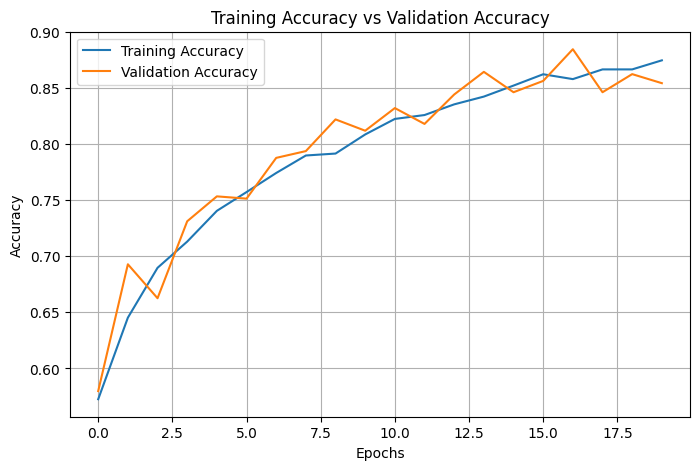

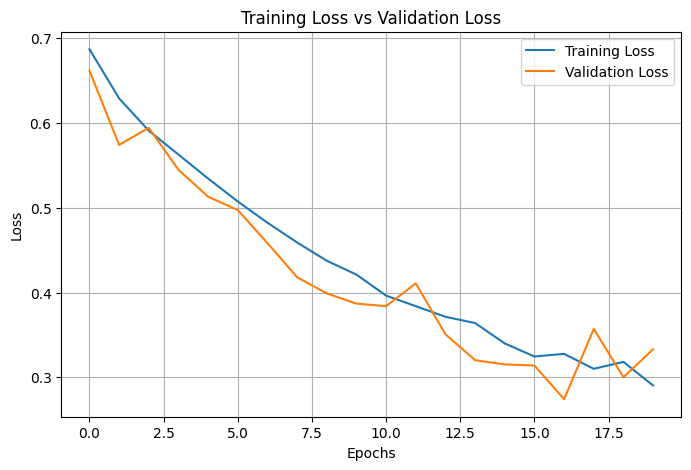

In [44]:
# ============================================================
# CELL 11 : Training Visualization
# Purpose:
# - Plot Training vs Validation Accuracy
# - Plot Training vs Validation Loss
# - Analyze overfitting/underfitting
# ============================================================


# -------------------------------
# Extract History Values
# -------------------------------

acc = history.history["accuracy"]

val_acc = history.history["val_accuracy"]


loss = history.history["loss"]

val_loss = history.history["val_loss"]


epochs_range = range(len(acc))


# ============================================================
# Graph 1 : Accuracy Curve
# ============================================================

plt.figure(figsize=(8,5))


plt.plot(
    epochs_range,
    acc,
    label="Training Accuracy"
)


plt.plot(
    epochs_range,
    val_acc,
    label="Validation Accuracy"
)


plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title(
    "Training Accuracy vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()



# ============================================================
# Graph 2 : Loss Curve
# ============================================================

plt.figure(figsize=(8,5))


plt.plot(
    epochs_range,
    loss,
    label="Training Loss"
)


plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss"
)


plt.xlabel("Epochs")

plt.ylabel("Loss")


plt.title(
    "Training Loss vs Validation Loss"
)


plt.legend()

plt.grid()

plt.show()

In [45]:
# ============================================================
# CELL 12 : Model Evaluation
# Purpose:
# - Evaluate final CNN performance on unseen test images
# - Calculate Loss, Accuracy, Precision, Recall, AUC
# ============================================================


# Load best saved model

best_model = tf.keras.models.load_model(
    "best_leaf_model.keras"
)


# Evaluate on test dataset

test_results = best_model.evaluate(
    test_ds,
    verbose=1
)


# Get metric names

metric_names = best_model.metrics_names


print("\nTest Performance")
print("="*40)


for name,value in zip(
    metric_names,
    test_results
):

    print(
        f"{name} : {value:.4f}"
    )

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8729 - loss: 0.2913

Test Performance
loss : 0.2913
compile_metrics : 0.8729


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Confusion Matrix
[[453  45]
 [ 81 412]]


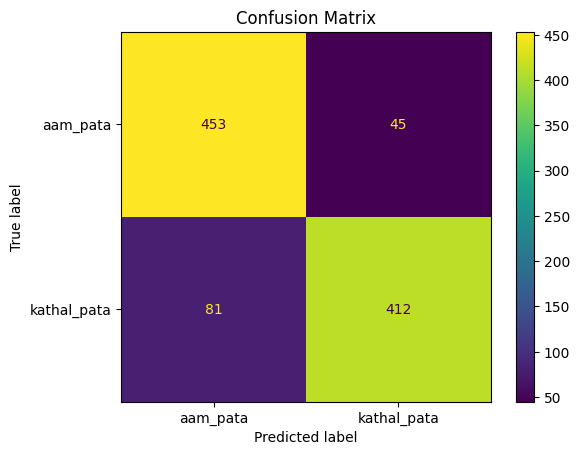

              precision    recall  f1-score   support

    aam_pata       0.85      0.91      0.88       498
 kathal_pata       0.90      0.84      0.87       493

    accuracy                           0.87       991
   macro avg       0.87      0.87      0.87       991
weighted avg       0.87      0.87      0.87       991



In [46]:
# ============================================================
# CELL 13 : Confusion Matrix & Classification Report
# Purpose:
# - Generate predictions
# - Compare Actual vs Predicted labels
# - Calculate Precision, Recall, F1-score
# ============================================================


# -------------------------------
# True Labels
# -------------------------------

y_true = []


for images, labels in test_ds:

    y_true.extend(
        labels.numpy()
    )


y_true = np.array(y_true)



# -------------------------------
# Predictions
# -------------------------------

y_probability = best_model.predict(
    test_ds
)


# Convert probability to class

y_pred = (y_probability > 0.5).astype(int)


y_pred = y_pred.reshape(-1)



# -------------------------------
# Confusion Matrix
# -------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)


print("Confusion Matrix")

print(cm)



# Display Matrix

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


disp.plot()

plt.title(
    "Confusion Matrix"
)

plt.show()



# -------------------------------
# Classification Report
# -------------------------------


print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Actual Class : kathal_pata
Image Path : /content/leaf_dataset/test/kathal_pata/image2041.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step

Prediction : kathal_pata
Confidence : 99.89%


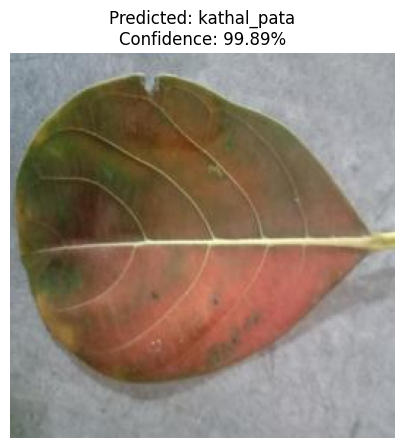

In [47]:
# ============================================================
# CELL 14 : Random Test Image Prediction
# Purpose:
# - Pick random image from test dataset
# - Predict leaf class
# ============================================================


import random
from tensorflow.keras.preprocessing import image


# Load best model

model = tf.keras.models.load_model(
    "best_leaf_model.keras"
)


# -------------------------------
# Select Random Test Image
# -------------------------------

random_class = random.choice(class_names)

random_image = random.choice(
    os.listdir(
        os.path.join(TEST_DIR, random_class)
    )
)


IMAGE_PATH = os.path.join(
    TEST_DIR,
    random_class,
    random_image
)


print("Actual Class :", random_class)
print("Image Path :", IMAGE_PATH)



# -------------------------------
# Load Image
# -------------------------------

img = image.load_img(
    IMAGE_PATH,
    target_size=(256,256)
)



img_array = image.img_to_array(
    img
)


img_array = np.expand_dims(
    img_array,
    axis=0
)



# -------------------------------
# Prediction
# -------------------------------

prediction = model.predict(
    img_array
)


probability = prediction[0][0]


if probability >= 0.5:

    predicted_class = "kathal_pata"

    confidence = probability*100

else:

    predicted_class = "aam_pata"

    confidence = (1-probability)*100



print("\nPrediction :", predicted_class)

print(
    f"Confidence : {confidence:.2f}%"
)



# -------------------------------
# Display Image
# -------------------------------

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.axis("off")

plt.title(
    f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()

In [48]:
train_acc = history.history['accuracy'][-1]

val_acc = history.history['val_accuracy'][-1]


print("Training Accuracy:", train_acc)

print("Validation Accuracy:", val_acc)

print(
    "Difference:",
    train_acc-val_acc
)

Training Accuracy: 0.8749277591705322
Validation Accuracy: 0.8545454740524292
Difference: 0.020382285118103027


In [49]:
train_loss = history.history['loss'][-1]

val_loss = history.history['val_loss'][-1]


print(train_loss)

print(val_loss)

0.2904179096221924
0.33314049243927
